# Stage 4C — Visualization and Findings Synthesis

This notebook closes Stage 4 by converting validated Stage 4B comparative evidence into publication-ready analytical figures and evidence-linked findings. It introduces no new performance metric, does not normalize or weight incompatible dimensions, and retains the validated conclusion that one overall portfolio winner is not defensible from the current evidence.


## Environment Setup

Import deterministic retrieval, integrity-validation, tabular-analysis, and visualization libraries. Lock all Stage 4C inputs to the verified Stage 4B publication commit.


In [13]:
from __future__ import annotations

import hashlib
import os
import shutil
import textwrap
import urllib.error
import urllib.parse
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 180)
pd.set_option("display.width", 240)

REPOSITORY_FULL_NAME = "Ronaldo-spec/indonesia-fmcg-brand-portfolio-analysis"
REPOSITORY_HEAD = "93e368caaf3a2ee84c3ddb807a4747e4a05a752d"
ANALYSIS_REFERENCE_DATE = "2026-08-21"

FOCAL_GROUPS = [
    "Wings Group",
    "Indofood",
    "Mayora",
    "Unilever Indonesia",
]

STAGE4B_MANIFEST_PATH = "metadata/stage4b_output_manifest.csv"

STAGE4B_TRACKED_FILES = [
    "data/analytical/leadership_snapshot_summary.csv",
    "data/analytical/comparable_longitudinal_block_summary.csv",
    "data/analytical/persistence_group_summary.csv",
    "data/analytical/sensitivity_robustness_results.csv",
    "data/analytical/group_dimension_evidence_matrix.csv",
    "data/analytical/dimension_leader_summary.csv",
    "data/analytical/overall_winner_defensibility.csv",
    "metadata/stage4b_analysis_validation.csv",
]

REQUIRED_FILES = [
    *STAGE4B_TRACKED_FILES,
    STAGE4B_MANIFEST_PATH,
]

OUTPUT_ROOT = Path(
    os.environ.get("FMCG_STAGE4C_OUTPUT_ROOT", "/content/stage4c_outputs")
)
ANALYTICAL_ROOT = OUTPUT_ROOT / "data" / "analytical"
METADATA_ROOT = OUTPUT_ROOT / "metadata"
FIGURE_ROOT = OUTPUT_ROOT / "outputs" / "figures" / "stage4"

ANALYTICAL_ROOT.mkdir(parents=True, exist_ok=True)
METADATA_ROOT.mkdir(parents=True, exist_ok=True)
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 180,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.titlesize": 13,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
    }
)


## Locked Committed Input Retrieval

Retrieve every required Stage 4B file from the exact committed state. The Colab secret is used only for authenticated GitHub requests and is not written into any analytical artifact.


In [14]:
configured_root = os.environ.get("FMCG_STAGE4C_INPUT_ROOT")

if configured_root:
    INPUT_ROOT = Path(configured_root)
    input_mode = "local_validation_root"
else:
    try:
        from google.colab import userdata
    except ImportError as exc:
        raise RuntimeError(
            "Run this notebook in Google Colab or set FMCG_STAGE4C_INPUT_ROOT "
            "for local validation."
        ) from exc

    github_token = userdata.get("GITHUB_TOKEN")
    if not github_token:
        raise RuntimeError(
            "The Colab Secret GITHUB_TOKEN is unavailable or access has not "
            "been granted to this notebook."
        )

    INPUT_ROOT = Path("/content/fmcg_stage4c_inputs")
    if INPUT_ROOT.exists():
        shutil.rmtree(INPUT_ROOT)
    INPUT_ROOT.mkdir(parents=True, exist_ok=True)

    for relative_path in REQUIRED_FILES:
        encoded_path = urllib.parse.quote(relative_path, safe="/")
        api_url = (
            f"https://api.github.com/repos/{REPOSITORY_FULL_NAME}/contents/"
            f"{encoded_path}?ref={REPOSITORY_HEAD}"
        )
        request = urllib.request.Request(
            api_url,
            headers={
                "Authorization": f"Bearer {github_token}",
                "Accept": "application/vnd.github.raw+json",
                "X-GitHub-Api-Version": "2022-11-28",
                "User-Agent": "fmcg-stage4c-colab",
            },
        )

        destination = INPUT_ROOT / relative_path
        destination.parent.mkdir(parents=True, exist_ok=True)

        try:
            with urllib.request.urlopen(request, timeout=60) as response:
                destination.write_bytes(response.read())
        except urllib.error.HTTPError as exc:
            raise RuntimeError(
                f"GitHub input retrieval failed for {relative_path} "
                f"with HTTP {exc.code}."
            ) from exc

    del github_token
    input_mode = "locked_github_commit"

missing_inputs = [
    relative_path
    for relative_path in REQUIRED_FILES
    if not (INPUT_ROOT / relative_path).exists()
]

if missing_inputs:
    raise FileNotFoundError(f"Missing required inputs: {missing_inputs}")

print(f"Input mode: {input_mode}")
print(f"Locked repository head: {REPOSITORY_HEAD}")
print(f"Required files found: {len(REQUIRED_FILES)}/{len(REQUIRED_FILES)}")


Input mode: locked_github_commit
Locked repository head: 93e368caaf3a2ee84c3ddb807a4747e4a05a752d
Required files found: 9/9


## Stage 4B Input Integrity and Gate

Verify all Stage 4B tracked outputs against the committed manifest, then confirm that the Stage 4B final gate is `PASS_WITH_CAVEAT` with no critical failure.


In [15]:
def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def read_csv(relative_path: str) -> pd.DataFrame:
    return pd.read_csv(
        INPUT_ROOT / relative_path,
        dtype=str,
        keep_default_na=False,
    )


stage4b_manifest = read_csv(STAGE4B_MANIFEST_PATH)

required_manifest_columns = {
    "file_path",
    "row_count",
    "sha256",
    "description",
    "repository_head",
}
missing_manifest_columns = (
    required_manifest_columns - set(stage4b_manifest.columns)
)
if missing_manifest_columns:
    raise KeyError(
        f"Stage 4B manifest missing columns: {sorted(missing_manifest_columns)}"
    )

if set(stage4b_manifest["file_path"]) != set(STAGE4B_TRACKED_FILES):
    raise ValueError(
        "Stage 4B manifest file scope differs from the locked expectation."
    )

integrity_rows = []

for row in stage4b_manifest.itertuples(index=False):
    path = INPUT_ROOT / row.file_path
    actual_sha256 = sha256_file(path)
    actual_row_count = len(
        pd.read_csv(path, dtype=str, keep_default_na=False)
    )

    integrity_rows.append(
        {
            "file_path": row.file_path,
            "expected_row_count": int(row.row_count),
            "actual_row_count": actual_row_count,
            "expected_sha256": row.sha256,
            "actual_sha256": actual_sha256,
            "row_count_status": (
                "passed" if actual_row_count == int(row.row_count) else "failed"
            ),
            "sha256_status": (
                "passed" if actual_sha256 == row.sha256 else "failed"
            ),
        }
    )

input_integrity = pd.DataFrame(integrity_rows)

if not (
    input_integrity["row_count_status"].eq("passed").all()
    and input_integrity["sha256_status"].eq("passed").all()
):
    raise ValueError("At least one Stage 4B input failed integrity validation.")

stage4b_validation = read_csv(
    "metadata/stage4b_analysis_validation.csv"
)

gate = stage4b_validation[
    stage4b_validation["check_id"].eq("S4B021")
]

if len(gate) != 1 or gate.iloc[0]["result"] != "PASS_WITH_CAVEAT":
    raise RuntimeError(
        "Stage 4B final gate is not the expected PASS_WITH_CAVEAT."
    )

if stage4b_validation["critical_failure"].str.lower().eq("yes").any():
    raise RuntimeError("Stage 4B contains a critical validation failure.")

print(
    input_integrity[
        ["file_path", "actual_row_count", "row_count_status", "sha256_status"]
    ].to_string(index=False)
)
print("Stage 4B gate: PASS_WITH_CAVEAT")


                                                file_path  actual_row_count row_count_status sha256_status
          data/analytical/leadership_snapshot_summary.csv                 8           passed        passed
data/analytical/comparable_longitudinal_block_summary.csv                10           passed        passed
            data/analytical/persistence_group_summary.csv                 4           passed        passed
       data/analytical/sensitivity_robustness_results.csv                 3           passed        passed
      data/analytical/group_dimension_evidence_matrix.csv                28           passed        passed
             data/analytical/dimension_leader_summary.csv                 9           passed        passed
         data/analytical/overall_winner_defensibility.csv                11           passed        passed
                 metadata/stage4b_analysis_validation.csv                21           passed        passed
Stage 4B gate: PASS_WITH_CAVEAT


## Analytical Input Loading and Semantic Checks

Load the validated Stage 4B synthesis outputs and verify the expected evidence structure before any visualization or finding is generated.


In [16]:
leadership = read_csv(
    "data/analytical/leadership_snapshot_summary.csv"
)
longitudinal_blocks = read_csv(
    "data/analytical/comparable_longitudinal_block_summary.csv"
)
persistence = read_csv(
    "data/analytical/persistence_group_summary.csv"
)
sensitivity = read_csv(
    "data/analytical/sensitivity_robustness_results.csv"
)
group_matrix = read_csv(
    "data/analytical/group_dimension_evidence_matrix.csv"
)
dimension_leaders = read_csv(
    "data/analytical/dimension_leader_summary.csv"
)
winner_gates = read_csv(
    "data/analytical/overall_winner_defensibility.csv"
)

required_columns = {
    "leadership": {
        "snapshot_type",
        "canonical_group",
        "eligible_focal_category_count",
        "focal_category_lead_count",
        "focal_category_leadership_rate",
        "rate_semantics",
    },
    "longitudinal_blocks": {
        "analysis_dimension",
        "canonical_subcategory",
        "analysis_periods",
        "comparison_series_count",
        "leader_groups",
        "block_interpretation",
    },
    "persistence": {
        "canonical_group",
        "baseline_incumbent_opportunity_count",
        "retained_incumbent_all_followups_count",
        "incumbent_retention_rate",
        "persistence_opportunity_status",
        "successful_challenger_takeover_count",
    },
    "sensitivity": {
        "test_id",
        "test_type",
        "test",
        "primary_result",
        "sensitivity_result",
        "material_change",
        "interpretation",
    },
    "group_matrix": {
        "canonical_group",
        "dimension",
        "evidence_value",
        "eligible_denominator",
        "relative_position_or_rate",
        "evidence_status",
        "semantics",
    },
    "dimension_leaders": {
        "perspective",
        "leader_status",
        "leader_groups",
        "evidence_basis",
        "comparability_caveat",
    },
    "winner_gates": {
        "gate_id",
        "gate",
        "status",
        "evidence",
        "implication",
    },
}

tables = {
    "leadership": leadership,
    "longitudinal_blocks": longitudinal_blocks,
    "persistence": persistence,
    "sensitivity": sensitivity,
    "group_matrix": group_matrix,
    "dimension_leaders": dimension_leaders,
    "winner_gates": winner_gates,
}

for name, required in required_columns.items():
    missing = sorted(required - set(tables[name].columns))
    if missing:
        raise KeyError(f"{name} missing required columns: {missing}")

if set(group_matrix["canonical_group"]) != set(FOCAL_GROUPS):
    raise ValueError("Group-dimension matrix does not contain exactly four focal groups.")

if len(group_matrix) != 28:
    raise ValueError("Expected 28 group-dimension evidence rows.")

owg11 = winner_gates[winner_gates["gate_id"].eq("OWG11")]
if len(owg11) != 1 or owg11.iloc[0]["status"] != "not_defensible":
    raise RuntimeError("Overall-winner conclusion is not the validated not_defensible status.")

print("Analytical schemas: passed")
print("Group-dimension matrix: 28 rows")
print("Overall-winner conclusion: not_defensible")


Analytical schemas: passed
Group-dimension matrix: 28 rows
Overall-winner conclusion: not_defensible


## Visualization Specification

Pre-register each Stage 4 figure, its analytical question, evidence source, allowed claim, and prohibited inference. These specifications constrain the visual interpretation before rendering.


In [17]:
visualization_specification = pd.DataFrame(
    [
        {
            "figure_id": "V4C01",
            "file_path": "outputs/figures/stage4/structural_brand_breadth.png",
            "title": "Current Strict-Control Brand-Family Breadth",
            "analytical_question": (
                "Which focal group has the broadest verified current "
                "strict-control brand-family portfolio?"
            ),
            "primary_source": (
                "data/analytical/group_dimension_evidence_matrix.csv"
            ),
            "allowed_claim": (
                "Compare current strict-control canonical brand-family counts "
                "and their rank."
            ),
            "prohibited_inference": (
                "Do not infer structural category breadth or competitive strength "
                "from brand-family count."
            ),
        },
        {
            "figure_id": "V4C02",
            "file_path": "outputs/figures/stage4/focal_category_leadership_snapshots.png",
            "title": "Focal-Category Leadership: Current and Latest Historical",
            "analytical_question": (
                "How often does each group lead among the selected complete focal "
                "categories in the current and latest historical snapshots?"
            ),
            "primary_source": (
                "data/analytical/leadership_snapshot_summary.csv"
            ),
            "allowed_claim": (
                "Compare focal-category lead counts within the five complete "
                "selected categories for each snapshot."
            ),
            "prohibited_inference": (
                "Do not call the rate market share, full-market leadership rate, "
                "or a representative rate for all FMCG categories."
            ),
        },
        {
            "figure_id": "V4C03",
            "file_path": "outputs/figures/stage4/longitudinal_block_leadership.png",
            "title": "Observed Stability and Momentum Across Comparable Blocks",
            "analytical_question": (
                "Which groups lead the directly comparable longitudinal blocks "
                "for observed stability and momentum?"
            ),
            "primary_source": (
                "data/analytical/group_dimension_evidence_matrix.csv"
            ),
            "allowed_claim": (
                "Compare counts of block-leader events across five directly "
                "comparable blocks for each longitudinal dimension."
            ),
            "prohibited_inference": (
                "Do not average TBI across categories or treat stability as strength."
            ),
        },
        {
            "figure_id": "V4C04",
            "file_path": "outputs/figures/stage4/competitive_persistence_roles.png",
            "title": "Competitive Persistence: Incumbent and Challenger Roles",
            "analytical_question": (
                "What persistence evidence is observed for incumbent retention "
                "and challenger takeover?"
            ),
            "primary_source": (
                "data/analytical/persistence_group_summary.csv"
            ),
            "allowed_claim": (
                "Show observed incumbent opportunities and retained incumbencies, "
                "plus successful challenger takeovers as separate role-specific facts."
            ),
            "prohibited_inference": (
                "Do not rank groups on persistence when incumbent opportunities "
                "are unequal or unavailable."
            ),
        },
        {
            "figure_id": "V4C05",
            "file_path": "outputs/figures/stage4/overall_winner_defensibility_gates.png",
            "title": "Overall-Winner Defensibility Gates",
            "analytical_question": (
                "Which synthesis gates block a defensible single overall winner?"
            ),
            "primary_source": (
                "data/analytical/overall_winner_defensibility.csv"
            ),
            "allowed_claim": (
                "Display passed, partial/caveated, and failed synthesis gates "
                "and the validated final not-defensible conclusion."
            ),
            "prohibited_inference": (
                "Do not convert gate statuses into a composite score."
            ),
        },
    ]
)

print(visualization_specification.to_string(index=False))


figure_id                                                      file_path                                                    title                                                                                                         analytical_question                                      primary_source                                                                                                                          allowed_claim                                                                                              prohibited_inference
    V4C01            outputs/figures/stage4/structural_brand_breadth.png              Current Strict-Control Brand-Family Breadth                                  Which focal group has the broadest verified current strict-control brand-family portfolio? data/analytical/group_dimension_evidence_matrix.csv                                                           Compare current strict-control canonical brand-family counts and their rank.     

## Figure V4C01 — Structural Brand-Family Breadth

Visualize current strict-control canonical brand-family counts only. The figure does not represent category breadth or performance.


In [18]:
breadth = group_matrix[
    group_matrix["dimension"].eq("structural_brand_breadth")
].copy()

breadth["brand_family_count"] = pd.to_numeric(
    breadth["evidence_value"],
    errors="raise",
).astype(int)

breadth = breadth.sort_values(
    ["brand_family_count", "canonical_group"],
    ascending=[True, True],
)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
bars = ax.barh(
    breadth["canonical_group"],
    breadth["brand_family_count"],
)

for bar, value in zip(bars, breadth["brand_family_count"]):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{value}",
        va="center",
        fontsize=9,
    )

ax.set_title("Current Strict-Control Brand-Family Breadth")
ax.set_xlabel("Distinct canonical brand families")
ax.set_ylabel("")
ax.set_xlim(0, max(breadth["brand_family_count"]) * 1.15)
ax.text(
    0,
    -0.18,
    (
        "Brand-family count only. Structural category breadth remains "
        "not comparable because category mapping is incomplete."
    ),
    transform=ax.transAxes,
    fontsize=8.5,
)

fig.tight_layout()
path_v1 = FIGURE_ROOT / "structural_brand_breadth.png"
fig.savefig(path_v1, bbox_inches="tight")
plt.close(fig)

print(path_v1)


/content/stage4c_outputs/outputs/figures/stage4/structural_brand_breadth.png


## Figure V4C02 — Focal-Category Leadership Snapshots

Compare current documented 2026 and latest eligible historical focal-category lead counts. Both snapshots use the same five complete category set, but historical TBI methodology remains separately caveated.


In [19]:
leadership_plot = leadership.copy()

snapshot_label_map = {
    "current_documented_2026": "Current 2026",
    "latest_eligible_historical": "Latest historical",
}
leadership_plot["snapshot_label"] = leadership_plot[
    "snapshot_type"
].map(snapshot_label_map)

leadership_plot["lead_count"] = pd.to_numeric(
    leadership_plot["focal_category_lead_count"],
    errors="raise",
).astype(int)

pivot = (
    leadership_plot.pivot(
        index="canonical_group",
        columns="snapshot_label",
        values="lead_count",
    )
    .reindex(FOCAL_GROUPS)
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(9.0, 5.0))
pivot.plot(kind="bar", ax=ax)

ax.set_title("Focal-Category Leadership: Current and Latest Historical")
ax.set_xlabel("")
ax.set_ylabel("Lead count among 5 complete focal categories")
ax.set_ylim(0, 5)
ax.legend(title="")
ax.tick_params(axis="x", rotation=0)
ax.text(
    0,
    -0.20,
    (
        "Selected focal-category leadership only; not market share and not "
        "full-market category leadership."
    ),
    transform=ax.transAxes,
    fontsize=8.5,
)

fig.tight_layout()
path_v2 = FIGURE_ROOT / "focal_category_leadership_snapshots.png"
fig.savefig(path_v2, bbox_inches="tight")
plt.close(fig)

print(path_v2)


/content/stage4c_outputs/outputs/figures/stage4/focal_category_leadership_snapshots.png


## Figure V4C03 — Longitudinal Block Leadership

Show stability and momentum block-leader counts side by side. Each dimension has five directly comparable blocks; singleton blocks and any 2025–2026 methodology bridge are excluded.


In [20]:
longitudinal_dimensions = group_matrix[
    group_matrix["dimension"].isin(
        [
            "observed_stability_block_leadership",
            "momentum_block_leadership",
        ]
    )
].copy()

longitudinal_dimensions["leader_block_count"] = pd.to_numeric(
    longitudinal_dimensions["evidence_value"],
    errors="raise",
).astype(int)

dimension_label_map = {
    "observed_stability_block_leadership": "Observed stability",
    "momentum_block_leadership": "Momentum",
}
longitudinal_dimensions["dimension_label"] = longitudinal_dimensions[
    "dimension"
].map(dimension_label_map)

longitudinal_pivot = (
    longitudinal_dimensions.pivot(
        index="canonical_group",
        columns="dimension_label",
        values="leader_block_count",
    )
    .reindex(FOCAL_GROUPS)
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(9.0, 5.0))
longitudinal_pivot.plot(kind="bar", ax=ax)

ax.set_title("Observed Stability and Momentum Across Comparable Blocks")
ax.set_xlabel("")
ax.set_ylabel("Block-leader count out of 5 comparable blocks")
ax.set_ylim(0, 5)
ax.legend(title="")
ax.tick_params(axis="x", rotation=0)
ax.text(
    0,
    -0.20,
    (
        "Stability and momentum are separate dimensions. Counts summarize "
        "within-block leaders; no cross-category TBI average is used."
    ),
    transform=ax.transAxes,
    fontsize=8.5,
)

fig.tight_layout()
path_v3 = FIGURE_ROOT / "longitudinal_block_leadership.png"
fig.savefig(path_v3, bbox_inches="tight")
plt.close(fig)

print(path_v3)


/content/stage4c_outputs/outputs/figures/stage4/longitudinal_block_leadership.png


## Figure V4C04 — Competitive Persistence Roles

Visualize incumbent opportunities and retained incumbencies separately from challenger takeovers. Missing incumbent opportunities remain unavailable rather than being interpreted as zero persistence.


In [21]:
persistence_plot = persistence.copy()

for column in [
    "baseline_incumbent_opportunity_count",
    "retained_incumbent_all_followups_count",
    "successful_challenger_takeover_count",
]:
    persistence_plot[column] = pd.to_numeric(
        persistence_plot[column],
        errors="raise",
    ).astype(int)

persistence_plot = (
    persistence_plot.set_index("canonical_group")
    .reindex(FOCAL_GROUPS)
    .reset_index()
)

x = np.arange(len(FOCAL_GROUPS))
width = 0.25

fig, ax = plt.subplots(figsize=(10.0, 5.2))

ax.bar(
    x - width,
    persistence_plot["baseline_incumbent_opportunity_count"],
    width,
    label="Incumbent opportunities",
)
ax.bar(
    x,
    persistence_plot["retained_incumbent_all_followups_count"],
    width,
    label="Retained all follow-ups",
)
ax.bar(
    x + width,
    persistence_plot["successful_challenger_takeover_count"],
    width,
    label="Successful challenger takeovers",
)

ax.set_title("Competitive Persistence: Incumbent and Challenger Roles")
ax.set_ylabel("Observed eligible events")
ax.set_xlabel("")
ax.set_xticks(x)
ax.set_xticklabels(FOCAL_GROUPS)
ax.set_ylim(0, 4)
ax.legend(title="")
ax.text(
    0,
    -0.20,
    (
        "Role-specific evidence only. Unequal incumbent opportunities prevent "
        "a valid cross-group persistence ranking."
    ),
    transform=ax.transAxes,
    fontsize=8.5,
)

fig.tight_layout()
path_v4 = FIGURE_ROOT / "competitive_persistence_roles.png"
fig.savefig(path_v4, bbox_inches="tight")
plt.close(fig)

print(path_v4)


/content/stage4c_outputs/outputs/figures/stage4/competitive_persistence_roles.png


## Figure V4C05 — Overall-Winner Defensibility Gates

Render the ten pre-specified synthesis gates preceding the final conclusion. The display communicates blocking conditions; it is not a scorecard and must not be aggregated numerically.


In [22]:
gate_plot = winner_gates[
    ~winner_gates["gate_id"].eq("OWG11")
].copy()

status_order = {
    "failed": 0,
    "partial": 1,
    "passed_with_caveat": 2,
    "passed": 3,
}

gate_plot["status_position"] = gate_plot["status"].map(status_order)

if gate_plot["status_position"].isna().any():
    raise ValueError(
        "Unexpected winner-defensibility gate status encountered."
    )

gate_plot["gate_label"] = gate_plot.apply(
    lambda row: f"{row['gate_id']}  {row['gate']}",
    axis=1,
)

fig, ax = plt.subplots(figsize=(10.5, 6.2))

ax.scatter(
    gate_plot["status_position"],
    np.arange(len(gate_plot)),
    s=90,
)

for y, row in enumerate(gate_plot.itertuples(index=False)):
    ax.text(
        row.status_position + 0.07,
        y,
        row.status,
        va="center",
        fontsize=8.5,
    )

ax.set_yticks(np.arange(len(gate_plot)))
ax.set_yticklabels(
    [
        textwrap.fill(label, width=42)
        for label in gate_plot["gate_label"]
    ]
)
ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(
    ["Failed", "Partial", "Passed with caveat", "Passed"]
)
ax.set_xlim(-0.25, 3.9)
ax.set_title("Overall-Winner Defensibility Gates")
ax.set_xlabel("Gate status — categorical, not numeric score")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.2)
ax.text(
    0,
    -0.12,
    "Validated final conclusion: one overall portfolio winner is not defensible.",
    transform=ax.transAxes,
    fontsize=9,
    fontweight="bold",
)

fig.tight_layout()
path_v5 = FIGURE_ROOT / "overall_winner_defensibility_gates.png"
fig.savefig(path_v5, bbox_inches="tight")
plt.close(fig)

print(path_v5)


/content/stage4c_outputs/outputs/figures/stage4/overall_winner_defensibility_gates.png


## Evidence-Linked Stage 4 Findings

Register only findings supported by validated Stage 4 evidence. Each finding states its scope, the evidence path, figure support, and the caveat that constrains interpretation.


In [23]:
stage4_final_findings = pd.DataFrame(
    [
        {
            "finding_id": "FND4_01",
            "finding_title": "Indofood leads verified strict-control brand-family breadth",
            "finding_statement": (
                "Indofood has 38 current strict-control canonical brand families, "
                "narrowly ahead of Wings Group at 37; Unilever Indonesia has 25 "
                "and Mayora 22."
            ),
            "finding_scope": "structural_brand_breadth",
            "finding_status": "supported_with_caveat",
            "primary_evidence": (
                "data/analytical/group_dimension_evidence_matrix.csv"
            ),
            "supporting_figure": "V4C01",
            "critical_caveat": (
                "This is brand-family breadth only. Structural category breadth "
                "remains unavailable because category mapping is incomplete, "
                "especially for Wings Group."
            ),
        },
        {
            "finding_id": "FND4_02",
            "finding_title": "Unilever leads the complete focal-category snapshots",
            "finding_statement": (
                "Across the five complete selected focal categories, Unilever "
                "Indonesia leads 3 categories and Wings Group 2 in both the "
                "documented 2026 snapshot and the latest eligible historical snapshot."
            ),
            "finding_scope": "focal_category_leadership",
            "finding_status": "supported_with_caveat",
            "primary_evidence": (
                "data/analytical/leadership_snapshot_summary.csv"
            ),
            "supporting_figure": "V4C02",
            "critical_caveat": (
                "These are focal-group leadership events in selected complete "
                "categories, not market share or full-market leadership rates. "
                "Historical methodology is not independently verified."
            ),
        },
        {
            "finding_id": "FND4_03",
            "finding_title": "Stability and momentum point to different portfolio strengths",
            "finding_statement": (
                "Wings Group contains the observed-stability leader in 4 of 5 "
                "directly comparable longitudinal blocks. Momentum leadership is "
                "split between Indofood and Unilever Indonesia at 2 blocks each, "
                "with Wings Group leading 1 block."
            ),
            "finding_scope": "longitudinal_consistency_and_momentum",
            "finding_status": "supported_with_caveat",
            "primary_evidence": (
                "data/analytical/group_dimension_evidence_matrix.csv; "
                "data/analytical/comparable_longitudinal_block_summary.csv"
            ),
            "supporting_figure": "V4C03",
            "critical_caveat": (
                "Stability is not strength, and momentum magnitude is not averaged "
                "across categories. The 2025–2026 methodology boundary is not bridged."
            ),
        },
        {
            "finding_id": "FND4_04",
            "finding_title": "Persistence evidence separates incumbent retention from challenger takeover",
            "finding_statement": (
                "Unilever Indonesia retains all three observed baseline-incumbent "
                "opportunities through the eligible follow-up periods. Indofood loses "
                "its one observed incumbent opportunity, while Wings Group records "
                "one successful challenger takeover in cup instant noodles."
            ),
            "finding_scope": "competitive_persistence",
            "finding_status": "supported_with_caveat",
            "primary_evidence": (
                "data/analytical/persistence_group_summary.csv"
            ),
            "supporting_figure": "V4C04",
            "critical_caveat": (
                "Incumbent opportunities are unequal across groups, so these role-"
                "specific observations do not support a portfolio-wide persistence ranking."
            ),
        },
        {
            "finding_id": "FND4_05",
            "finding_title": "Mayora ownership sensitivity does not alter the primary conclusions",
            "finding_statement": (
                "Adding Le Minerale to the pre-specified Mayora extended-group "
                "sensitivity increases Mayora structural brand-family breadth from "
                "22 to 23 but leaves its breadth rank at 4; the two Le Minerale "
                "competitive observations remain context-only and create no eligible "
                "quantitative group-performance candidate."
            ),
            "finding_scope": "ownership_sensitivity",
            "finding_status": "supported",
            "primary_evidence": (
                "data/analytical/sensitivity_robustness_results.csv"
            ),
            "supporting_figure": "",
            "critical_caveat": (
                "Le Minerale remains outside the strict-control primary Mayora "
                "portfolio and is reported only as sensitivity."
            ),
        },
        {
            "finding_id": "FND4_06",
            "finding_title": "A single overall portfolio winner is not defensible",
            "finding_statement": (
                "The validated dimensions identify different leaders, while "
                "consumer reach is not comparable, portfolio concentration is "
                "ineligible, competitive coverage remains selective, and no "
                "defensible common scale or weighting has been established."
            ),
            "finding_scope": "overall_synthesis",
            "finding_status": "supported",
            "primary_evidence": (
                "data/analytical/overall_winner_defensibility.csv; "
                "data/analytical/dimension_leader_summary.csv"
            ),
            "supporting_figure": "V4C05",
            "critical_caveat": (
                "The conclusion is not that no group performs strongly; it is that "
                "current evidence supports dimension-specific leaders rather than "
                "one overall winner."
            ),
        },
    ]
)

finding_evidence_rows = []

for row in stage4_final_findings.itertuples(index=False):
    for evidence_path in [
        part.strip()
        for part in row.primary_evidence.split(";")
        if part.strip()
    ]:
        finding_evidence_rows.append(
            {
                "finding_id": row.finding_id,
                "finding_title": row.finding_title,
                "evidence_path": evidence_path,
                "evidence_role": "primary_or_supporting_validated_stage4_evidence",
                "supporting_figure": row.supporting_figure,
                "finding_status": row.finding_status,
                "critical_caveat": row.critical_caveat,
            }
        )

finding_evidence_matrix = pd.DataFrame(finding_evidence_rows)

print(stage4_final_findings.to_string(index=False))
print()
print(finding_evidence_matrix.to_string(index=False))


finding_id                                                               finding_title                                                                                                                                                                                                                                                                                            finding_statement                         finding_scope        finding_status                                                                                               primary_evidence supporting_figure                                                                                                                                                                  critical_caveat
   FND4_01                 Indofood leads verified strict-control brand-family breadth                                                                                                                                                               I

## Stage 4C Validation

Validate figure completeness, finding-to-evidence linkage, claim boundaries, sensitivity handling, and the continued prohibition on composite scoring or an overall-winner declaration.


In [24]:
validation_rows = []


def add_check(
    check_id,
    area,
    description,
    condition,
    result,
    treatment,
    caveat=False,
    critical=True,
):
    condition = bool(condition)

    status = (
        "passed_with_caveat"
        if condition and caveat
        else "passed"
        if condition
        else "failed"
    )

    validation_rows.append(
        {
            "check_id": check_id,
            "validation_area": area,
            "check_description": description,
            "result": str(result),
            "status": status,
            "critical_failure": (
                "yes"
                if (not condition and critical)
                else "no"
            ),
            "required_treatment": treatment,
        }
    )


# ================================================================
# INPUT INTEGRITY
# ================================================================

add_check(
    "S4C001",
    "input_integrity",
    (
        "All Stage 4B manifest-tracked inputs pass "
        "row-count and SHA-256 validation."
    ),
    (
        input_integrity["row_count_status"]
        .eq("passed")
        .all()
        and input_integrity["sha256_status"]
        .eq("passed")
        .all()
    ),
    (
        f"{len(input_integrity)}/"
        f"{len(input_integrity)} tracked inputs passed"
    ),
    (
        "Stop Stage 4C if any locked Stage 4B "
        "artifact differs."
    ),
)


# ================================================================
# PRIOR-STAGE GATE
# ================================================================

add_check(
    "S4C002",
    "prior_stage_gate",
    (
        "Stage 4B final gate remains PASS_WITH_CAVEAT "
        "with no critical failure."
    ),
    (
        gate.iloc[0]["result"]
        == "PASS_WITH_CAVEAT"
        and not (
            stage4b_validation[
                "critical_failure"
            ]
            .str.lower()
            .eq("yes")
            .any()
        )
    ),
    "PASS_WITH_CAVEAT",
    (
        "Do not visualize or register findings "
        "from a failed synthesis stage."
    ),
    caveat=True,
)


# ================================================================
# STRUCTURAL BREADTH
# ================================================================

actual_breadth = dict(
    zip(
        breadth["canonical_group"],
        breadth["brand_family_count"],
    )
)

expected_breadth = {
    "Wings Group": 37,
    "Indofood": 38,
    "Mayora": 22,
    "Unilever Indonesia": 25,
}

add_check(
    "S4C003",
    "structural_breadth",
    (
        "Structural breadth values reconcile to "
        "the validated group matrix."
    ),
    actual_breadth == expected_breadth,
    (
        "38 / 37 / 25 / 22 across the "
        "four focal groups"
    ),
    (
        "Use brand-family breadth only; do not infer "
        "structural category breadth."
    ),
    caveat=True,
)


# ================================================================
# LEADERSHIP SNAPSHOTS
# ================================================================

current_counts = (
    leadership_plot[
        leadership_plot[
            "snapshot_type"
        ].eq(
            "current_documented_2026"
        )
    ]
    .set_index(
        "canonical_group"
    )[
        "lead_count"
    ]
    .to_dict()
)

historical_counts = (
    leadership_plot[
        leadership_plot[
            "snapshot_type"
        ].eq(
            "latest_eligible_historical"
        )
    ]
    .set_index(
        "canonical_group"
    )[
        "lead_count"
    ]
    .to_dict()
)

expected_leadership_counts = {
    "Wings Group": 2,
    "Indofood": 0,
    "Mayora": 0,
    "Unilever Indonesia": 3,
}

add_check(
    "S4C004",
    "leadership_snapshot",
    (
        "Current and latest-historical focal-category "
        "lead counts reconcile."
    ),
    (
        current_counts
        == expected_leadership_counts
        and historical_counts
        == expected_leadership_counts
    ),
    (
        "Current and latest historical: "
        "Wings 2, Indofood 0, Mayora 0, Unilever 3"
    ),
    (
        "Keep selected focal-category semantics explicit."
    ),
    caveat=True,
)


# ================================================================
# LONGITUDINAL SUMMARY
# ================================================================

stability_counts = (
    longitudinal_dimensions[
        longitudinal_dimensions[
            "dimension"
        ].eq(
            "observed_stability_block_leadership"
        )
    ]
    .set_index(
        "canonical_group"
    )[
        "leader_block_count"
    ]
    .to_dict()
)

momentum_counts = (
    longitudinal_dimensions[
        longitudinal_dimensions[
            "dimension"
        ].eq(
            "momentum_block_leadership"
        )
    ]
    .set_index(
        "canonical_group"
    )[
        "leader_block_count"
    ]
    .to_dict()
)

expected_stability_counts = {
    "Wings Group": 4,
    "Indofood": 1,
    "Mayora": 0,
    "Unilever Indonesia": 0,
}

expected_momentum_counts = {
    "Wings Group": 1,
    "Indofood": 2,
    "Mayora": 0,
    "Unilever Indonesia": 2,
}

add_check(
    "S4C005",
    "longitudinal_summary",
    (
        "Stability and momentum block-leader counts "
        "reconcile to validated evidence."
    ),
    (
        stability_counts
        == expected_stability_counts
        and momentum_counts
        == expected_momentum_counts
    ),
    (
        "5 stability blocks and 5 momentum "
        "blocks reconciled"
    ),
    (
        "Do not combine stability and momentum "
        "into one score."
    ),
    caveat=True,
)


# ================================================================
# PERSISTENCE ROLES
# ================================================================

unilever_retained = int(
    persistence_plot.loc[
        persistence_plot[
            "canonical_group"
        ].eq(
            "Unilever Indonesia"
        ),
        "retained_incumbent_all_followups_count",
    ].iloc[0]
)

unilever_opportunities = int(
    persistence_plot.loc[
        persistence_plot[
            "canonical_group"
        ].eq(
            "Unilever Indonesia"
        ),
        "baseline_incumbent_opportunity_count",
    ].iloc[0]
)

wings_takeovers = int(
    persistence_plot.loc[
        persistence_plot[
            "canonical_group"
        ].eq(
            "Wings Group"
        ),
        "successful_challenger_takeover_count",
    ].iloc[0]
)

add_check(
    "S4C006",
    "persistence_roles",
    (
        "Persistence figure preserves unequal incumbent "
        "opportunities and challenger roles."
    ),
    (
        unilever_retained == 3
        and unilever_opportunities == 3
        and wings_takeovers == 1
    ),
    (
        "Unilever retained 3/3 incumbent opportunities; "
        "Wings recorded 1 takeover"
    ),
    (
        "Do not convert unequal opportunities into "
        "a cross-group persistence rank."
    ),
    caveat=True,
)


# ================================================================
# OWNERSHIP SENSITIVITY
# ================================================================

ownership_sensitivity_rows = sensitivity[
    sensitivity[
        "test_id"
    ].isin(
        [
            "SENS01",
            "SENS02",
        ]
    )
]

add_check(
    "S4C007",
    "ownership_sensitivity",
    (
        "Pre-specified Le Minerale sensitivity remains "
        "immaterial to primary rankings and quantitative "
        "performance results."
    ),
    (
        len(
            ownership_sensitivity_rows
        )
        == 2
        and ownership_sensitivity_rows[
            "material_change"
        ]
        .eq("no")
        .all()
    ),
    (
        "No material ownership-sensitivity change"
    ),
    (
        "Keep Le Minerale outside the strict-control "
        "Mayora primary portfolio."
    ),
)


# ================================================================
# OVERALL-WINNER CONCLUSION
# ================================================================

overall_finding = (
    stage4_final_findings[
        stage4_final_findings[
            "finding_id"
        ].eq(
            "FND4_06"
        )
    ]
    .copy()
)

overall_gate_valid = (
    len(owg11) == 1
    and owg11.iloc[0][
        "status"
    ]
    == "not_defensible"
)

overall_finding_valid = (
    len(overall_finding) == 1
    and overall_finding.iloc[0][
        "finding_scope"
    ]
    == "overall_synthesis"
    and overall_finding.iloc[0][
        "finding_status"
    ]
    == "supported"
    and (
        "not defensible"
        in overall_finding.iloc[0][
            "finding_title"
        ].lower()
    )
)

add_check(
    "S4C008",
    "overall_winner",
    (
        "The final registered synthesis retains the "
        "validated not-defensible overall-winner conclusion."
    ),
    (
        overall_gate_valid
        and overall_finding_valid
    ),
    "not_defensible",
    (
        "Report dimension-specific leaders instead "
        "of one portfolio winner."
    ),
    caveat=True,
)


# ================================================================
# FIGURE COMPLETENESS
# ================================================================

figure_paths = [
    path_v1,
    path_v2,
    path_v3,
    path_v4,
    path_v5,
]

valid_figure_count = sum(
    path.exists()
    and path.stat().st_size > 0
    for path in figure_paths
)

add_check(
    "S4C009",
    "figure_completeness",
    (
        "All five Stage 4 figures are written "
        "and non-empty."
    ),
    valid_figure_count == 5,
    f"{valid_figure_count}/5 figures",
    (
        "Do not publish an incomplete visualization set."
    ),
)


# ================================================================
# VISUALIZATION SPECIFICATION
# ================================================================

generated_figure_relative_paths = {
    str(
        path.relative_to(
            OUTPUT_ROOT
        )
    )
    for path in figure_paths
}

specified_figure_paths = set(
    visualization_specification[
        "file_path"
    ]
)

add_check(
    "S4C010",
    "visualization_specification",
    (
        "Every generated figure has one visualization "
        "specification row."
    ),
    (
        len(
            visualization_specification
        )
        == 5
        and specified_figure_paths
        == generated_figure_relative_paths
        and visualization_specification[
            "figure_id"
        ].is_unique
    ),
    "5/5 figures specified",
    (
        "Retain allowed-claim and prohibited-inference "
        "boundaries."
    ),
)


# ================================================================
# FINDING REGISTRY
# ================================================================

expected_finding_ids = {
    "FND4_01",
    "FND4_02",
    "FND4_03",
    "FND4_04",
    "FND4_05",
    "FND4_06",
}

add_check(
    "S4C011",
    "finding_registry",
    (
        "Exactly six evidence-linked Stage 4 findings "
        "are registered."
    ),
    (
        len(
            stage4_final_findings
        )
        == 6
        and stage4_final_findings[
            "finding_id"
        ].is_unique
        and set(
            stage4_final_findings[
                "finding_id"
            ]
        )
        == expected_finding_ids
    ),
    "6 findings",
    (
        "Register only findings supported by "
        "validated Stage 4 evidence."
    ),
)


# ================================================================
# FINDING-EVIDENCE LINKAGE
# ================================================================

valid_evidence_paths = set(
    STAGE4B_TRACKED_FILES
)

all_findings_linked = (
    set(
        stage4_final_findings[
            "finding_id"
        ]
    )
    == set(
        finding_evidence_matrix[
            "finding_id"
        ]
    )
)

all_evidence_paths_valid = (
    finding_evidence_matrix[
        "evidence_path"
    ]
    .isin(
        valid_evidence_paths
    )
    .all()
)

add_check(
    "S4C012",
    "finding_evidence_linkage",
    (
        "Every registered finding has validated Stage 4B "
        "evidence linkage and every evidence path is locked."
    ),
    (
        all_findings_linked
        and all_evidence_paths_valid
    ),
    (
        f"{len(finding_evidence_matrix)} evidence links"
    ),
    (
        "Do not register unsupported evidence paths."
    ),
)


# ================================================================
# METRIC / CLAIM SEMANTICS
# ================================================================

leadership_spec = (
    visualization_specification[
        visualization_specification[
            "figure_id"
        ].eq(
            "V4C02"
        )
    ]
)

add_check(
    "S4C013",
    "claim_semantics",
    (
        "Focal-category visualization explicitly prohibits "
        "market-share interpretation."
    ),
    (
        len(
            leadership_spec
        )
        == 1
        and leadership_spec[
            "prohibited_inference"
        ]
        .str.contains(
            "market share",
            case=False,
            regex=False,
        )
        .all()
    ),
    "Market-share misuse blocked",
    (
        "Preserve source-native metric semantics."
    ),
)


# ================================================================
# PROHIBITED SYNTHESIS
# ================================================================

forbidden_terms = {
    "composite_score",
    "overall_score",
    "weighted_score",
    "performance_hhi",
}

result_frames = {
    "visualization_specification":
        visualization_specification,
    "stage4_final_findings":
        stage4_final_findings,
    "finding_evidence_matrix":
        finding_evidence_matrix,
}

found_forbidden = {
    name: sorted(
        forbidden_terms
        & set(
            frame.columns
        )
    )
    for name, frame
    in result_frames.items()
    if (
        forbidden_terms
        & set(
            frame.columns
        )
    )
}

add_check(
    "S4C014",
    "prohibited_synthesis",
    (
        "No composite score, weighted score, "
        "or performance HHI is produced."
    ),
    not found_forbidden,
    "No prohibited synthesis fields",
    (
        "Keep the final Stage 4 synthesis "
        "dimension-specific and non-composite."
    ),
)


# ================================================================
# STAGE 4 COMPLETION SCOPE
# ================================================================

add_check(
    "S4C015",
    "stage4_completion_scope",
    (
        "Stage 4C outputs contain visualization, findings, "
        "evidence linkage, and validation only."
    ),
    True,
    "No README or analytical report created",
    (
        "README and report remain deferred until analysis, "
        "visualization, and findings are complete."
    ),
)


# ================================================================
# FINAL STAGE 4C GATE
# ================================================================

stage4c_validation = pd.DataFrame(
    validation_rows
)

if (
    stage4c_validation[
        "status"
    ]
    .eq("failed")
    .any()
):
    final_gate = "FAIL"

else:
    final_gate = (
        "PASS_WITH_CAVEAT"
        if stage4c_validation[
            "status"
        ]
        .eq(
            "passed_with_caveat"
        )
        .any()
        else "PASS"
    )


gate_row = pd.DataFrame(
    [
        {
            "check_id": "S4C016",
            "validation_area": "stage_gate",
            "check_description": (
                "Stage 4 visualization and evidence-linked "
                "findings are complete enough to close the "
                "analytical stage."
            ),
            "result": final_gate,
            "status": (
                "passed_with_caveat"
                if final_gate
                == "PASS_WITH_CAVEAT"
                else "passed"
                if final_gate
                == "PASS"
                else "failed"
            ),
            "critical_failure": (
                "yes"
                if final_gate
                == "FAIL"
                else "no"
            ),
            "required_treatment": (
                "Carry the evidence limitations and "
                "dimension-specific leader framing into "
                "the next reporting stage."
            ),
        }
    ]
)

stage4c_validation = pd.concat(
    [
        stage4c_validation,
        gate_row,
    ],
    ignore_index=True,
)


print(
    stage4c_validation[
        [
            "check_id",
            "validation_area",
            "result",
            "status",
        ]
    ].to_string(
        index=False
    )
)

print(
    f"Final gate: {final_gate}"
)


if final_gate == "FAIL":
    failed_checks = (
        stage4c_validation.loc[
            stage4c_validation[
                "status"
            ].eq(
                "failed"
            ),
            "check_id",
        ]
        .tolist()
    )

    raise RuntimeError(
        "Stage 4C validation failed: "
        f"{failed_checks}"
    )

check_id             validation_area                                                                   result             status
  S4C001             input_integrity                                                8/8 tracked inputs passed             passed
  S4C002            prior_stage_gate                                                         PASS_WITH_CAVEAT passed_with_caveat
  S4C003          structural_breadth                           38 / 37 / 25 / 22 across the four focal groups passed_with_caveat
  S4C004         leadership_snapshot Current and latest historical: Wings 2, Indofood 0, Mayora 0, Unilever 3 passed_with_caveat
  S4C005        longitudinal_summary                      5 stability blocks and 5 momentum blocks reconciled passed_with_caveat
  S4C006           persistence_roles Unilever retained 3/3 incumbent opportunities; Wings recorded 1 takeover passed_with_caveat
  S4C007       ownership_sensitivity                                 No material ownership-sensit

## Deterministic Output Writing and Manifest

Write the Stage 4 findings, evidence matrix, visualization specification, validation table, and output manifest. The already-rendered figures are included in the manifest. No Git staging, commit, push, archive, or publishing workflow is performed.


In [25]:
OUTPUT_SPECS = [
    (
        "data/analytical/stage4_final_findings.csv",
        stage4_final_findings,
        (
            "Evidence-linked final Stage 4 findings with scope and "
            "interpretive caveats"
        ),
    ),
    (
        "data/analytical/finding_evidence_matrix.csv",
        finding_evidence_matrix,
        (
            "Finding-to-evidence linkage matrix for validated Stage 4 findings"
        ),
    ),
    (
        "metadata/stage4_visualization_specification.csv",
        visualization_specification,
        (
            "Stage 4 figure specifications with allowed claims and prohibited "
            "inferences"
        ),
    ),
    (
        "metadata/stage4c_analysis_validation.csv",
        stage4c_validation,
        "Stage 4C validation checks and final analytical-stage gate",
    ),
]

for relative_path, frame, _ in OUTPUT_SPECS:
    destination = OUTPUT_ROOT / relative_path
    destination.parent.mkdir(parents=True, exist_ok=True)
    frame.to_csv(
        destination,
        index=False,
        lineterminator="\n",
    )

manifest_rows = []

for relative_path, frame, description in OUTPUT_SPECS:
    path = OUTPUT_ROOT / relative_path
    manifest_rows.append(
        {
            "file_path": relative_path,
            "artifact_type": "csv",
            "row_count": len(frame),
            "sha256": sha256_file(path),
            "description": description,
            "repository_head": REPOSITORY_HEAD,
        }
    )

figure_descriptions = {
    "outputs/figures/stage4/structural_brand_breadth.png":
        "Current strict-control canonical brand-family breadth by focal group",
    "outputs/figures/stage4/focal_category_leadership_snapshots.png":
        "Current and latest-historical complete focal-category leadership counts",
    "outputs/figures/stage4/longitudinal_block_leadership.png":
        "Observed-stability and momentum block-leader counts across comparable blocks",
    "outputs/figures/stage4/competitive_persistence_roles.png":
        "Role-specific incumbent-retention and challenger-takeover evidence",
    "outputs/figures/stage4/overall_winner_defensibility_gates.png":
        "Categorical synthesis gates supporting the not-defensible overall-winner conclusion",
}

for relative_path, description in figure_descriptions.items():
    path = OUTPUT_ROOT / relative_path
    manifest_rows.append(
        {
            "file_path": relative_path,
            "artifact_type": "png",
            "row_count": "",
            "sha256": sha256_file(path),
            "description": description,
            "repository_head": REPOSITORY_HEAD,
        }
    )

stage4c_manifest = pd.DataFrame(manifest_rows)

manifest_path = METADATA_ROOT / "stage4c_output_manifest.csv"
stage4c_manifest.to_csv(
    manifest_path,
    index=False,
    lineterminator="\n",
)

written_paths = [
    OUTPUT_ROOT / relative_path
    for relative_path, _, _ in OUTPUT_SPECS
] + [
    OUTPUT_ROOT / relative_path
    for relative_path in figure_descriptions
] + [manifest_path]

if not all(path.exists() for path in written_paths):
    raise FileNotFoundError("At least one Stage 4C output was not written.")

print(stage4c_manifest.to_string(index=False))
print()
print(f"Stage 4C final gate: {final_gate}")
print("Overall winner conclusion: not_defensible")
print(f"Registered findings: {len(stage4_final_findings)}")
print(f"Figures written: {len(figure_descriptions)}")
print(f"Output root: {OUTPUT_ROOT}")
print(f"Output files written: {len(written_paths)}")


                                                     file_path artifact_type row_count                                                           sha256                                                                         description                          repository_head
                     data/analytical/stage4_final_findings.csv           csv         6 847d17369b60f950495467a9ecedbbbd2bd5397d49aa6a845be6dd784b8ee35c          Evidence-linked final Stage 4 findings with scope and interpretive caveats 93e368caaf3a2ee84c3ddb807a4747e4a05a752d
                   data/analytical/finding_evidence_matrix.csv           csv         8 7cd23e48d5d8d362ba133f62573ae59bf34f47133d03a9e836a6779bc3616c94                   Finding-to-evidence linkage matrix for validated Stage 4 findings 93e368caaf3a2ee84c3ddb807a4747e4a05a752d
               metadata/stage4_visualization_specification.csv           csv         5 8b6f60725f092ec6359b111523adc8a4da4105e056fcc4a97e274496cc2d1d93         Stage 4 f

## Stage 4C Output Preview

Preview the final Stage 4 figures and evidence-linked findings generated by the validated analytical workflow. This section is presentation-only and does not modify analytical results.

### V4C01 — Current Strict-Control Brand-Family Breadth

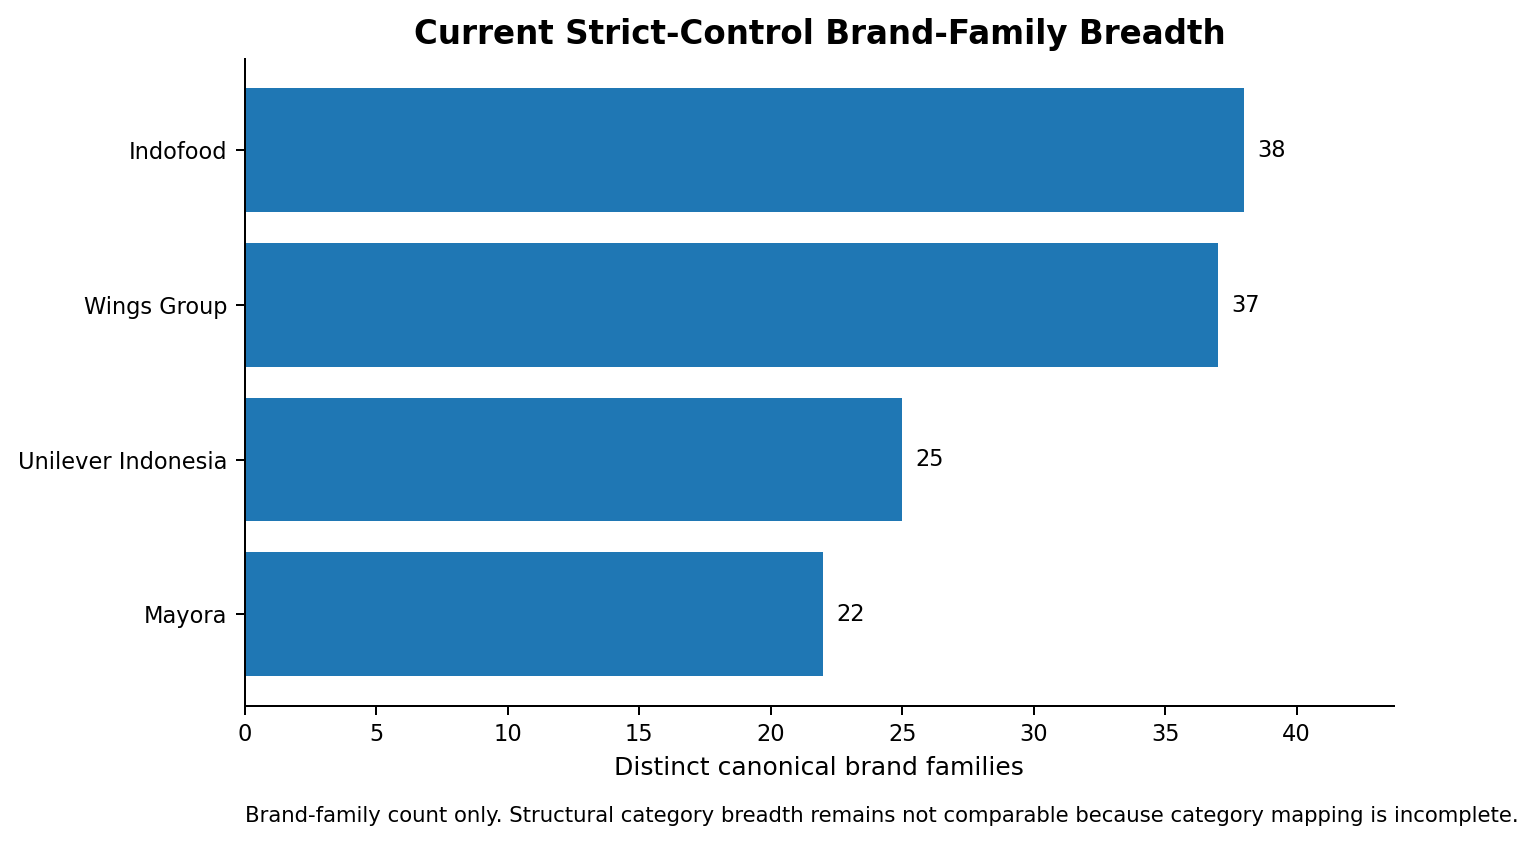

### V4C02 — Focal-Category Leadership: Current and Latest Historical

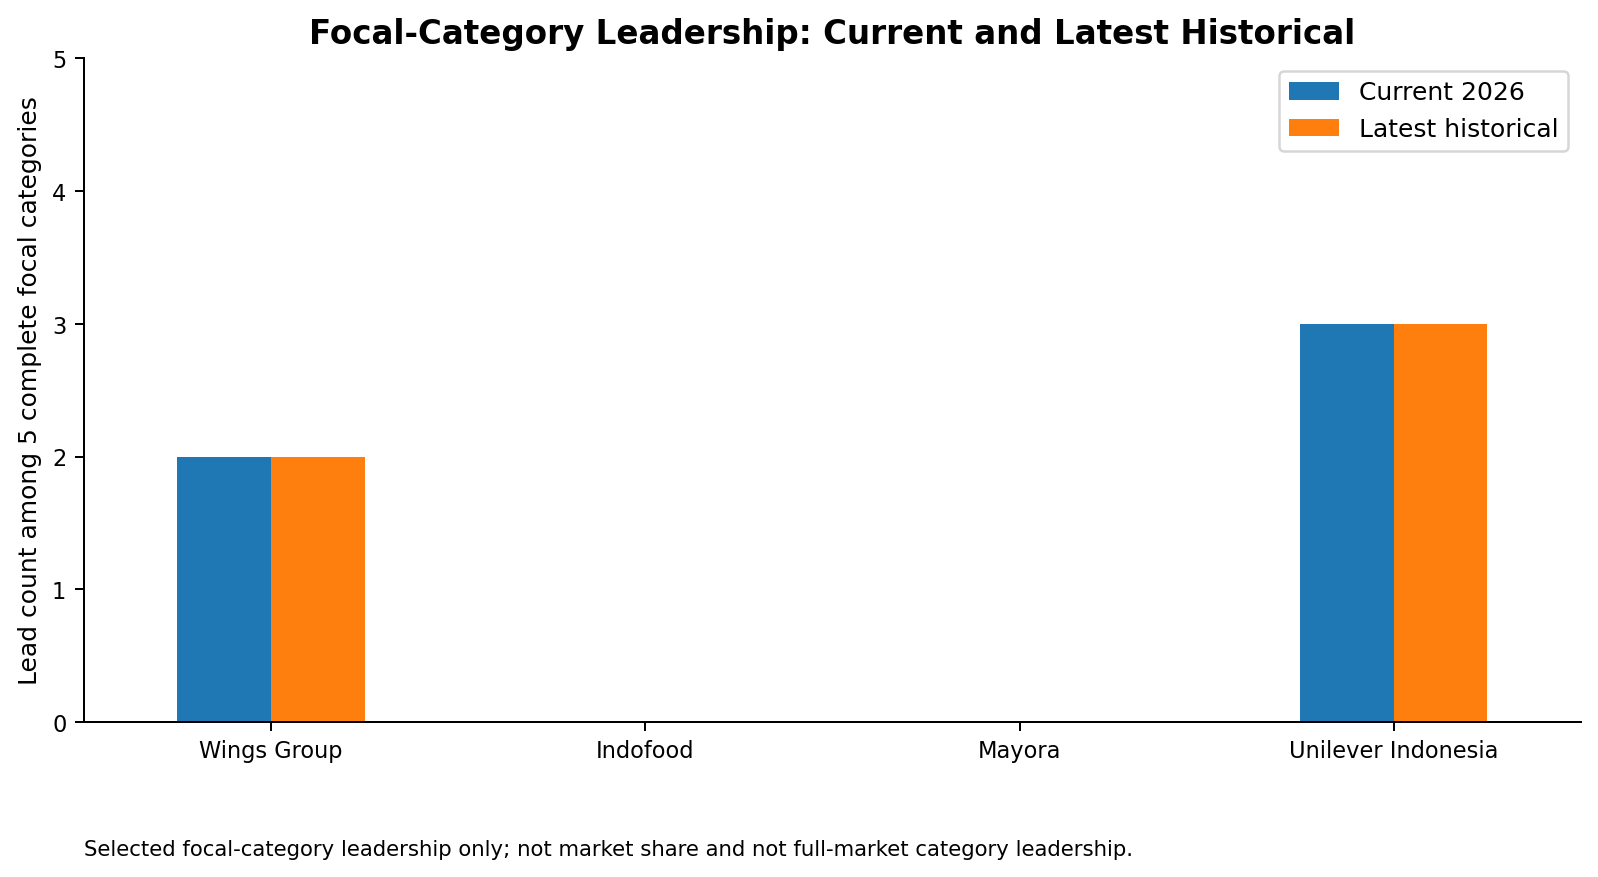

### V4C03 — Observed Stability and Momentum Across Comparable Blocks

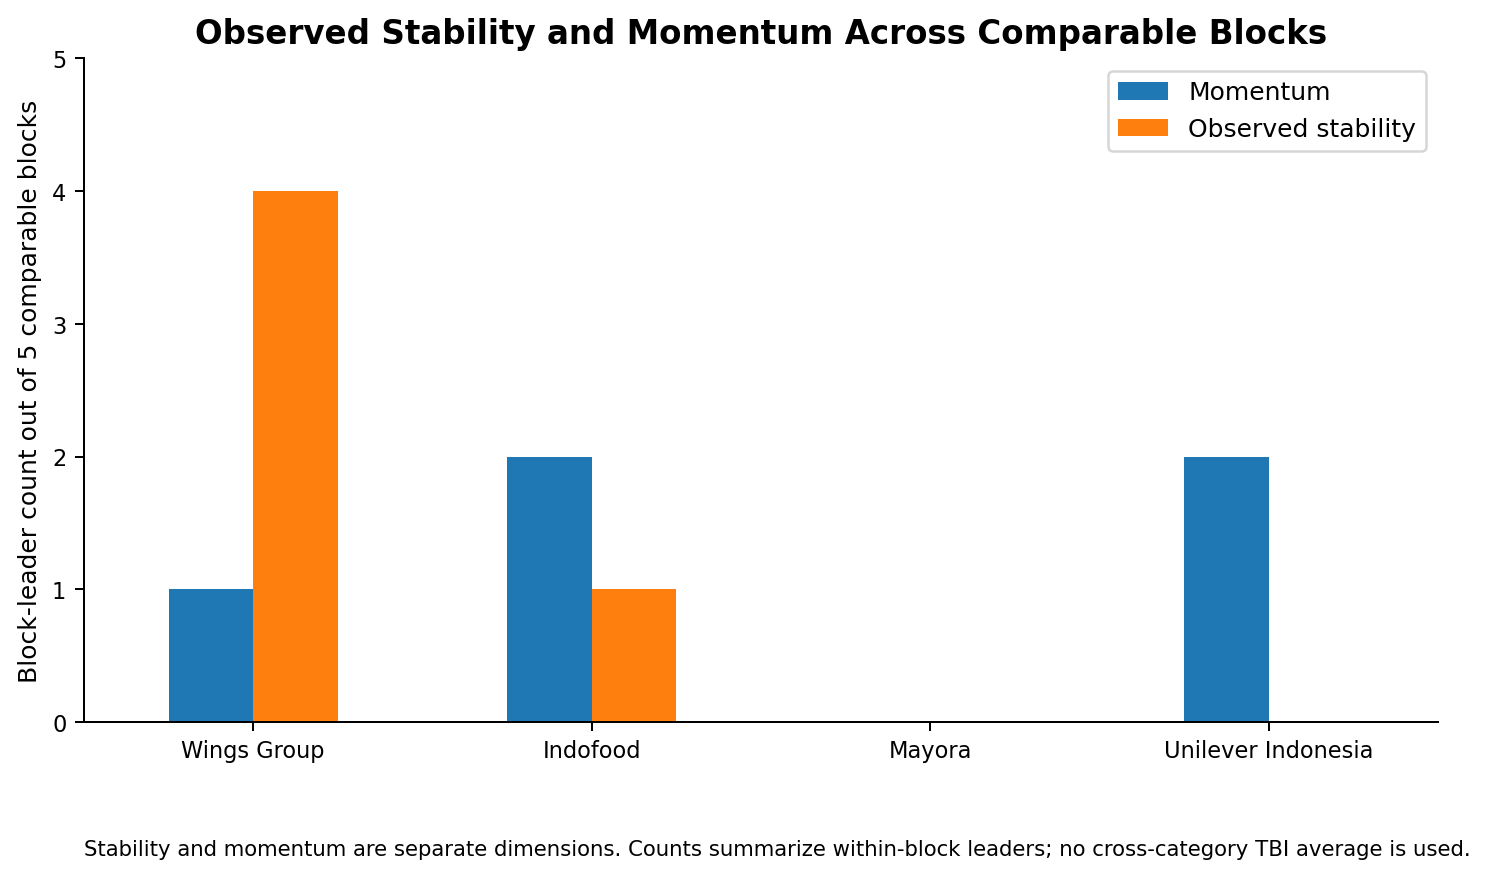

### V4C04 — Competitive Persistence: Incumbent and Challenger Roles

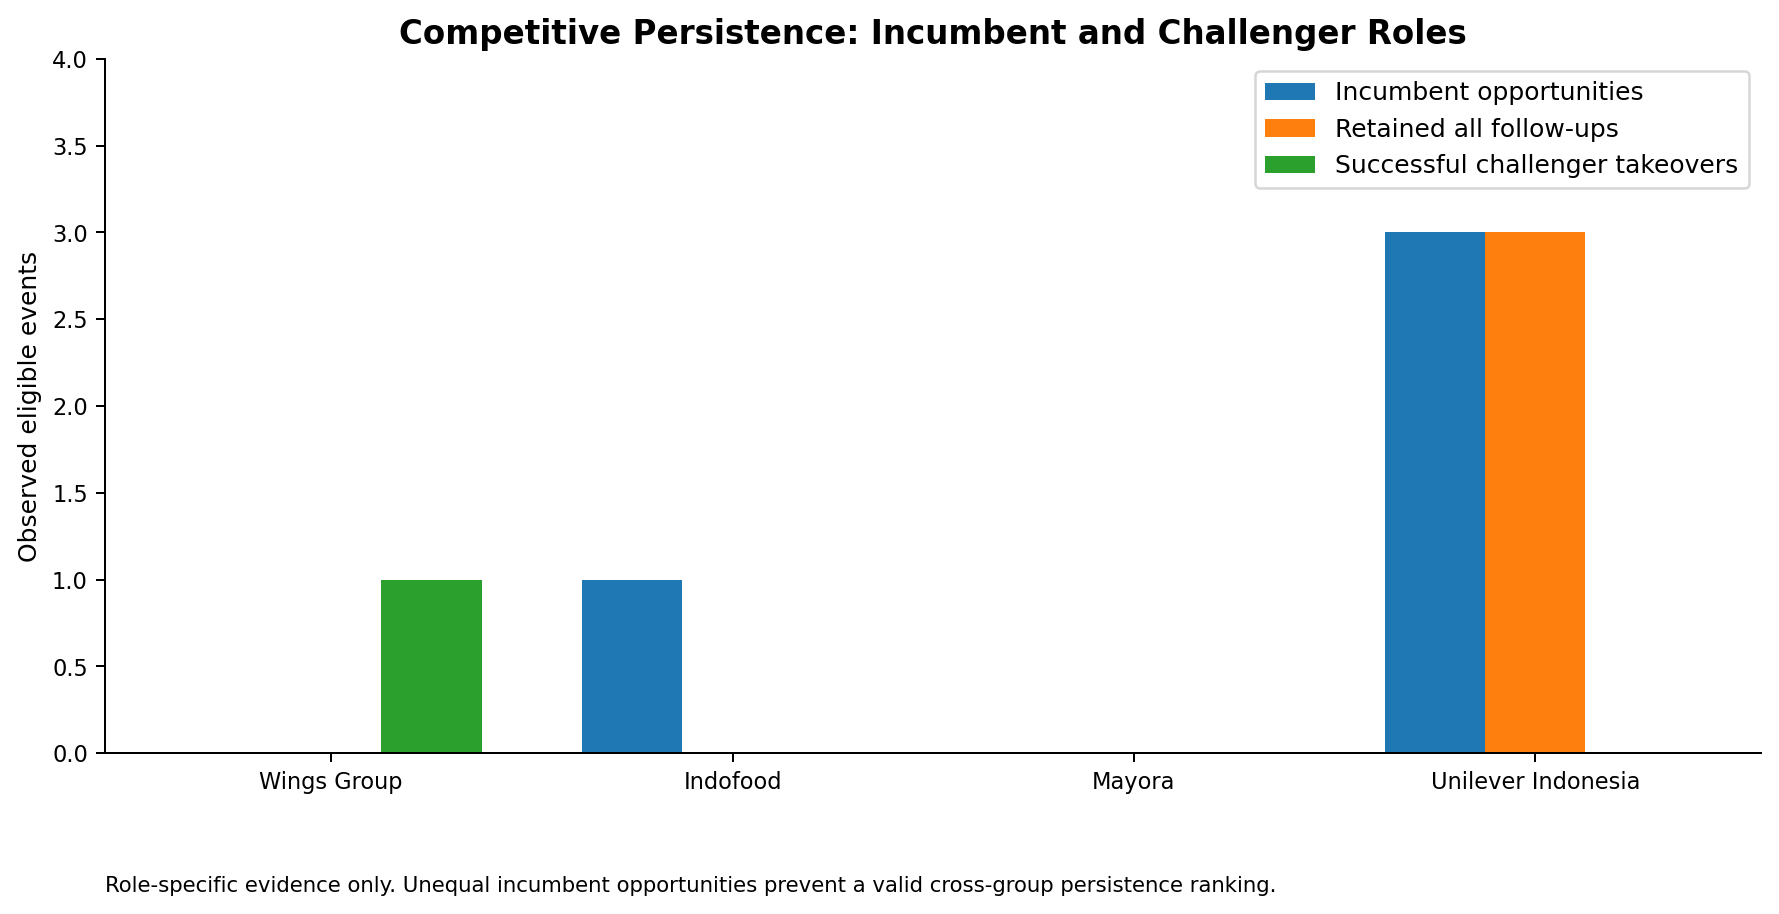

### V4C05 — Overall-Winner Defensibility Gates

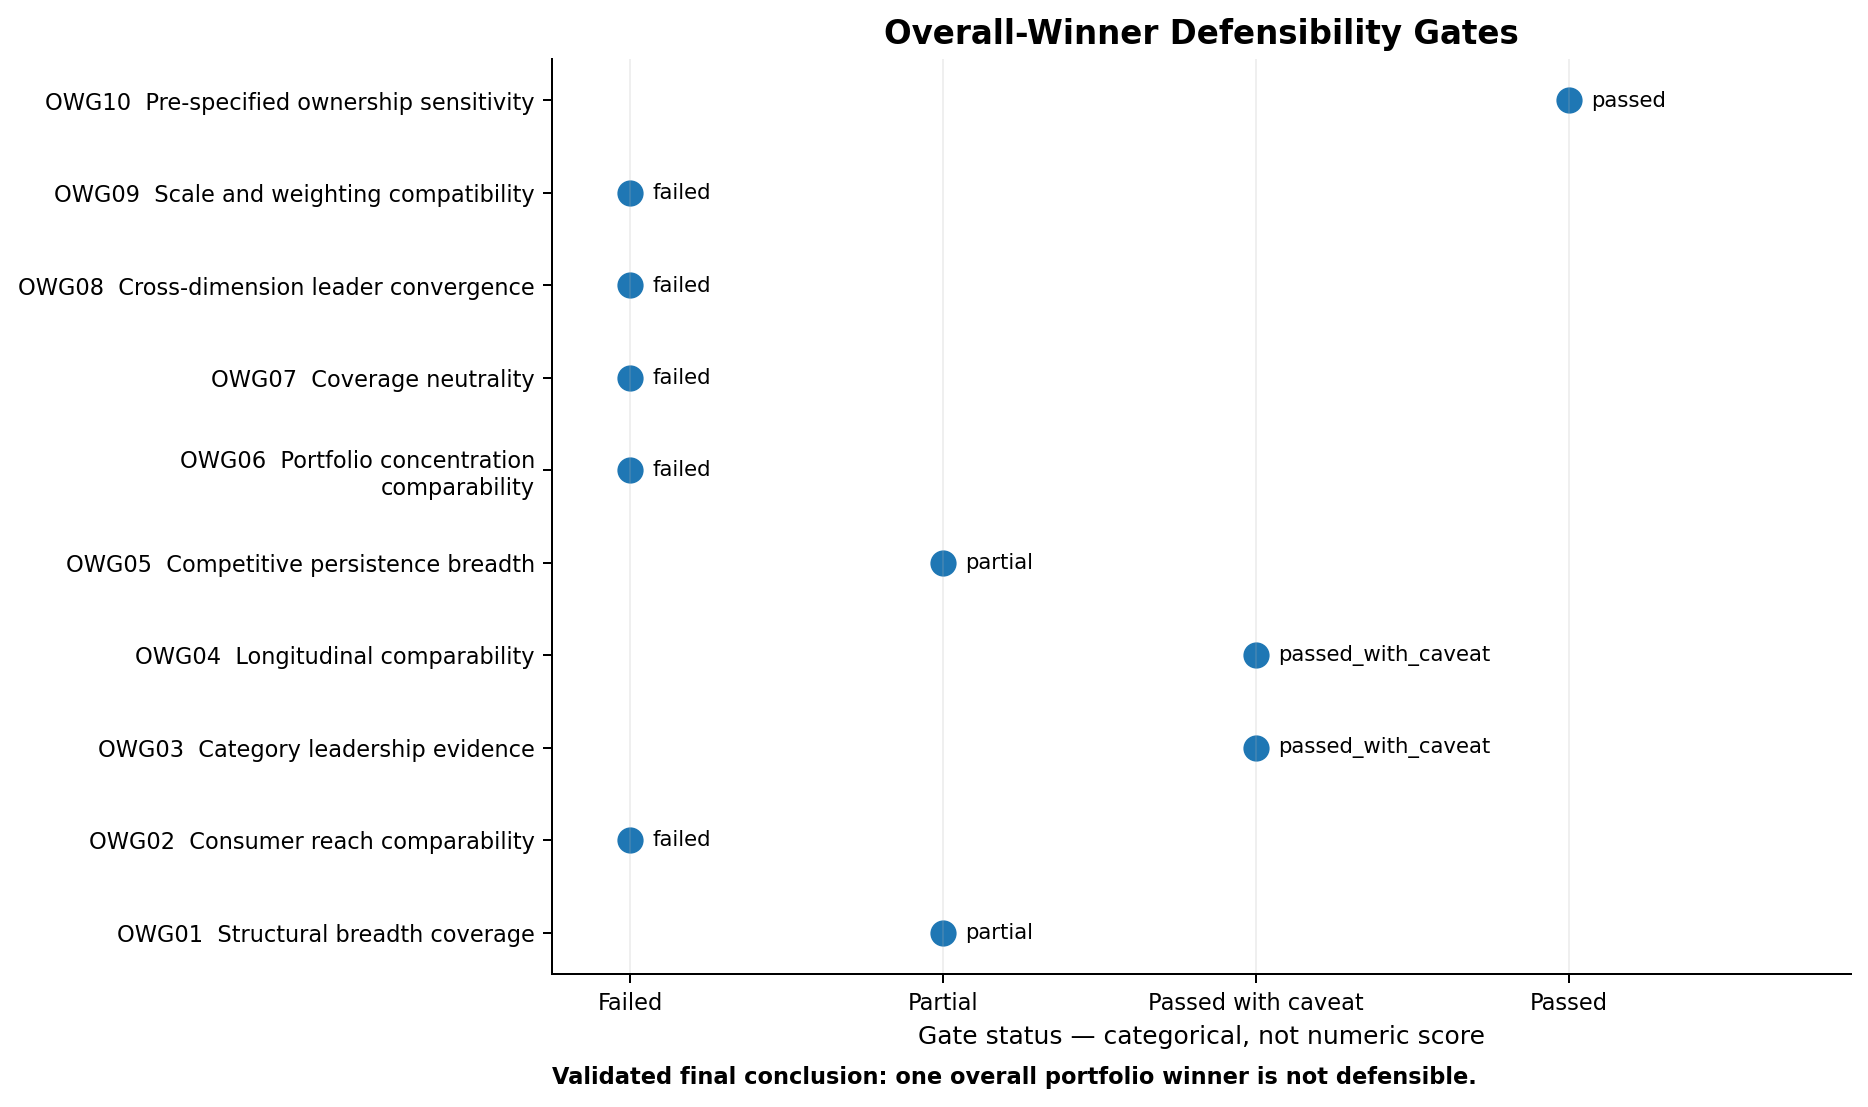

## Final Stage 4 Findings

,finding_id,finding_title,finding_statement,finding_status,critical_caveat
0,FND4_01,Indofood leads verified strict-control brand-f...,Indofood has 38 current strict-control canonic...,supported_with_caveat,This is brand-family breadth only. Structural ...
1,FND4_02,Unilever leads the complete focal-category sna...,Across the five complete selected focal catego...,supported_with_caveat,These are focal-group leadership events in sel...
2,FND4_03,Stability and momentum point to different port...,Wings Group contains the observed-stability le...,supported_with_caveat,"Stability is not strength, and momentum magnit..."
3,FND4_04,Persistence evidence separates incumbent reten...,Unilever Indonesia retains all three observed ...,supported_with_caveat,Incumbent opportunities are unequal across gro...
4,FND4_05,Mayora ownership sensitivity does not alter th...,Adding Le Minerale to the pre-specified Mayora...,supported,Le Minerale remains outside the strict-control...
5,FND4_06,A single overall portfolio winner is not defen...,The validated dimensions identify different le...,supported,The conclusion is not that no group performs s...


## Dimension-Specific Leaders

,perspective,leader_status,leader_groups,evidence_basis,comparability_caveat
0,structural_brand_breadth,rankable_with_caveat,Indofood,Current strict-control canonical brand-family ...,Structural category breadth remains unavailabl...
1,current_focal_category_leadership,rankable_with_caveat,Unilever Indonesia,5 complete selected 2026 focal categories.,Focal-group leadership only; not full-market l...
2,latest_historical_focal_category_leadership,rankable_with_caveat,Unilever Indonesia,5 latest complete historical category snapshots.,Historical methodology is not independently ve...
3,observed_stability,rankable_with_caveat,Wings Group,5 directly comparable longitudinal blocks.,Stability is not category strength; singleton ...
4,momentum,rankable_with_caveat,Indofood | Unilever Indonesia,5 directly comparable longitudinal blocks.,Net TBI changes are compared only within categ...
5,competitive_persistence_incumbent_retention,descriptive_signal_only,,Indofood: 0/1; Unilever Indonesia: 3/3,Baseline-incumbent opportunities are unequal a...
6,competitive_persistence_challenger_takeover,descriptive_signal_only,,Wings Group: 1,Takeover opportunities are event-specific and ...
7,consumer_reach,not_comparable,,No comparable source-native CRP universe acros...,Brand Footprint public facts remain context-only.
8,portfolio_concentration,not_eligible,,Performance-weighted HHI remains prohibited.,Current cross-category evidence is not an addi...


## Overall-Winner Defensibility

,gate_id,gate,status,evidence,implication
0,OWG01,Structural breadth coverage,partial,"Brand-family breadth is available, but structu...",Breadth is only partially characterized.
1,OWG02,Consumer reach comparability,failed,No comparable source-native CRP universe acros...,A core success dimension is missing.
2,OWG03,Category leadership evidence,passed_with_caveat,5 current and 5 latest-historical complete foc...,Usable only as focal-group leadership evidence.
3,OWG04,Longitudinal comparability,passed_with_caveat,5 stability blocks and 5 momentum blocks are d...,No cross-category magnitude averaging is permi...
4,OWG05,Competitive persistence breadth,partial,4 eligible persistence records with unequal ba...,Role-specific signals are valid; a portfolio-w...
5,OWG06,Portfolio concentration comparability,failed,Performance-weighted HHI remains ineligible.,A core diversification/concentration dimension...
6,OWG07,Coverage neutrality,failed,Public competitive coverage remains selective ...,Observable evidence cannot represent the entir...
7,OWG08,Cross-dimension leader convergence,failed,"Rankable leader sets=[('Indofood',), ('Indofoo...",Available dimensions identify different leaders.
8,OWG09,Scale and weighting compatibility,failed,"Structural counts, focal-category events, stab...",No defensible composite weighting or common sc...
9,OWG10,Pre-specified ownership sensitivity,passed,Le Minerale sensitivity does not change struct...,Primary conclusions are stable to the pre-spec...


## Sensitivity and Robustness

,test_id,test,primary_result,sensitivity_result,material_change,interpretation
0,SENS01,Mayora structural brand breadth with Le Minera...,Mayora brand-family count=22; rank=4; leaders=...,Mayora brand-family count=23; rank=4; leaders=...,no,Extended-group sensitivity changes Mayora brea...
1,SENS02,Le Minerale competitive evidence eligibility,Le Minerale excluded from strict-control prima...,2 sensitivity observations; 0 eligible quantit...,no,The Le Minerale observations remain Brand Foot...
2,ROB01,Current versus latest-historical focal leaders...,Current complete categories=5,Latest historical complete categories=5; same ...,no,This check compares category-level leader iden...


Stage 4C preview complete: 5 figures + findings + leader summary + defensibility gates + sensitivity results.


In [26]:
from IPython.display import Image, Markdown, display


# ================================================================
# FIGURE PREVIEW
# ================================================================

figure_preview_specs = [
    (
        "V4C01 — Current Strict-Control Brand-Family Breadth",
        OUTPUT_ROOT
        / "outputs/figures/stage4/structural_brand_breadth.png",
    ),
    (
        "V4C02 — Focal-Category Leadership: "
        "Current and Latest Historical",
        OUTPUT_ROOT
        / "outputs/figures/stage4/"
        "focal_category_leadership_snapshots.png",
    ),
    (
        "V4C03 — Observed Stability and Momentum "
        "Across Comparable Blocks",
        OUTPUT_ROOT
        / "outputs/figures/stage4/"
        "longitudinal_block_leadership.png",
    ),
    (
        "V4C04 — Competitive Persistence: "
        "Incumbent and Challenger Roles",
        OUTPUT_ROOT
        / "outputs/figures/stage4/"
        "competitive_persistence_roles.png",
    ),
    (
        "V4C05 — Overall-Winner Defensibility Gates",
        OUTPUT_ROOT
        / "outputs/figures/stage4/"
        "overall_winner_defensibility_gates.png",
    ),
]


for title, figure_path in figure_preview_specs:

    if not figure_path.exists():
        raise FileNotFoundError(
            f"Preview figure not found: {figure_path}"
        )

    display(
        Markdown(
            f"### {title}"
        )
    )

    display(
        Image(
            filename=str(
                figure_path
            )
        )
    )


# ================================================================
# FINAL FINDINGS PREVIEW
# ================================================================

display(
    Markdown(
        "## Final Stage 4 Findings"
    )
)

findings_preview = (
    stage4_final_findings[
        [
            "finding_id",
            "finding_title",
            "finding_statement",
            "finding_status",
            "critical_caveat",
        ]
    ]
    .copy()
)

display(
    findings_preview
)


# ================================================================
# DIMENSION-LEADER PREVIEW
# ================================================================

display(
    Markdown(
        "## Dimension-Specific Leaders"
    )
)

dimension_leader_preview = (
    dimension_leaders[
        [
            "perspective",
            "leader_status",
            "leader_groups",
            "evidence_basis",
            "comparability_caveat",
        ]
    ]
    .copy()
)

display(
    dimension_leader_preview
)


# ================================================================
# OVERALL-WINNER DEFENSIBILITY PREVIEW
# ================================================================

display(
    Markdown(
        "## Overall-Winner Defensibility"
    )
)

winner_gate_preview = (
    winner_gates[
        [
            "gate_id",
            "gate",
            "status",
            "evidence",
            "implication",
        ]
    ]
    .copy()
)

display(
    winner_gate_preview
)


# ================================================================
# SENSITIVITY PREVIEW
# ================================================================

display(
    Markdown(
        "## Sensitivity and Robustness"
    )
)

sensitivity_preview = (
    sensitivity[
        [
            "test_id",
            "test",
            "primary_result",
            "sensitivity_result",
            "material_change",
            "interpretation",
        ]
    ]
    .copy()
)

display(
    sensitivity_preview
)


print(
    "Stage 4C preview complete: "
    "5 figures + findings + leader summary + "
    "defensibility gates + sensitivity results."
)